Install glycowork, Import all necessary helper functions from glycowork, and Import additional dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
%matplotlib inline
import seaborn as sns
import networkx as nx
import os
!pip install "glycowork @ git+https://github.com/BojarLab/glycowork.git@dev"
import glycowork
from glycowork.glycan_data.loader import glycomics_data_loader
from glycowork.network.biosynthesis import construct_network, plot_network, export_network, highlight_network, trace_diamonds, find_diamonds, choose_path
from glycowork.motif.draw import GlycoDraw
from scipy import stats
from scipy.stats import ttest_rel, ttest_ind
from statsmodels.stats.multitest import multipletests
from IPython.display import display
from collections import defaultdict


  Cloning https://github.com/BojarLab/glycowork.git (to revision dev) to /tmp/pip-install-6y9hn8df/glycowork_748e2b85b4964be2b9fcdac68f9906ab
  Running command git clone --filter=blob:none --quiet https://github.com/BojarLab/glycowork.git /tmp/pip-install-6y9hn8df/glycowork_748e2b85b4964be2b9fcdac68f9906ab
  Running command git checkout -b dev --track origin/dev
  Switched to a new branch 'dev'
  Branch 'dev' set up to track remote branch 'dev' from 'origin'.
  Resolved https://github.com/BojarLab/glycowork.git to commit c6cccb00e4750d28a9a10f86f25f988dc130947a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.9/913.9 kB 12.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

Extract daimond reactions from network

In [2]:
#Function to extract reactions from diamond motifs in the network
def extract_diamond_reactions(net, diamonds):
    """
    Extract reactions from diamond motifs in the network.

    Parameters:
    net (networkx.Graph): The glycan biosynthesis network.
    diamonds (list of lists): List of diamond motifs, each containing nodes.

    Returns:
    list: A list of reactions associated with each diamond.
    """
    diamond_reactions = []
    for diamond in diamonds:
        reactions = []
        nodes = diamond

        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                if net.has_edge(nodes[i], nodes[j]):
                    reactions.append((nodes[i], nodes[j], net[nodes[i]][nodes[j]]['diffs'])) # Include start and end nodes with reaction
                elif net.has_edge(nodes[j], nodes[i]):
                    reactions.append((nodes[j], nodes[i], net[nodes[j]][nodes[i]]['diffs'])) # Include start and end nodes with reaction
        diamond_reactions.append(reactions)
    return diamond_reactions

Collect reaction preference data in the daimonds based on relative abundances

In [3]:
# Function to prepare the reaction preferences data for all samples
def collect_reaction_preferences_data(diamond_reactions, net, sample_name, data_source):
    """
    Collect the preferred order of reaction based on intermediate abundance in a formatted structure.

    Parameters:
    diamond_reactions (list of tuples): Reactions extracted from diamonds.
    net (networkx.Graph): The glycan biosynthesis network containing node data.
    sample_name (str): Name of the sample being processed.
    data_source (str): Source of the data.

    Returns:
    List[dict]: List of dictionaries containing the table data.
    """
    # List to store each row of table data
    table_data = []
    source_name = data_source.split('.')[-1]

    for idx, diamond_react in enumerate(diamond_reactions):
        start_node_groups = defaultdict(list)

        # Group reactions by start node
        for start_node, end_node, diffs in diamond_react:
            abundance = net.nodes[end_node].get('abundance')
            start_node_groups[start_node].append((end_node, diffs, abundance))

        # Compare the abundance of intermediates and determine preference
        for start_node, reactions in start_node_groups.items():
            if len(reactions) == 2:
                intermediate1, diff1, abundance1 = reactions[0]
                intermediate2, diff2, abundance2 = reactions[1]

                # Ensure abundance values exist
                if abundance1 is not None and abundance2 is not None:
                    if abundance1 > abundance2:
                        preference = "forward"
                    elif abundance2 > abundance1:
                        preference = "reverse"
                    else:
                        preference = "no preference"
                    table_data.append({
                        'Diamond at': start_node,
                        'Glycan reaction addition 1': diff1,
                        'Abundance of the reaction 1': abundance1,
                        'Glycan reaction addition 2': diff2,
                        'Abundance of the reaction 2': abundance2,
                        'Reaction Preference': preference,
                        'Sample Name': sample_name,
                        'Data Source': source_name
                    })

    return table_data

Load the data, construct the network for each sample, display the table with reaction preferences

In [4]:
# Load the data
df = glycomics_data_loader.human_skin_O_PMC5871710_BCC
# Main processing loop for all samples
all_data = []
data_source = 'glycomics_data_loader.human_skin_O_PMC5871710_BCC'
for sample_idx in range(1, df.shape[1]):
    sample_name = df.columns[sample_idx]

    # Construct the glycan network for the current sample
    abundances = df.iloc[:, sample_idx].values.tolist()
    net = construct_network(df.glycan.values.tolist(), abundances=abundances)

    # Find diamonds in the network
    diamonds = find_diamonds(net, mode="abundance")

    # Extract diamond reactions
    diamond_list = [list(d.values()) for d in diamonds]
    diamond_reactions = extract_diamond_reactions(net, diamond_list)

    # Collect reaction preferences data for each sample
    sample_data = collect_reaction_preferences_data(diamond_reactions, net, sample_name, data_source)
    all_data.extend(sample_data)
# Convert all collected data to a DataFrame
df_combined = pd.DataFrame(all_data)

# Sort the DataFrame by both 'Glycan reaction addition 1' and 'Glycan reaction addition 2'
df_combined = df_combined.sort_values(by=['Glycan reaction addition 1', 'Glycan reaction addition 2']).reset_index(drop=True)

# Display the sorted DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'center')
pd.set_option('display.max_colwidth', None)
display(df_combined)

,Diamond at,Glycan reaction addition 1,Abundance of the reaction 1,Glycan reaction addition 2,Abundance of the reaction 2,Reaction Preference,Sample Name,Data Source
0,Neu5Ac(a2-3)Gal(b1-3)[Gal(b1-4)GlcNAc(b1-6)]GalNAc,6S,12.401328,Neu5Ac(a2-3),0.843710,forward,control_1,human_skin_O_PMC5871710_BCC
1,Gal(b1-4)GlcNAc(b1-6)[Gal(b1-3)]GalNAc,6S,0.000000,Neu5Ac(a2-3),5.161248,reverse,control_1,human_skin_O_PMC5871710_BCC
2,Neu5Ac(a2-3)Gal(b1-3)[Gal(b1-4)GlcNAc(b1-6)]GalNAc,6S,33.010448,Neu5Ac(a2-3),1.185047,forward,tumor_1,human_skin_O_PMC5871710_BCC
3,Gal(b1-4)GlcNAc(b1-6)[Gal(b1-3)]GalNAc,6S,0.000000,Neu5Ac(a2-3),6.426154,reverse,tumor_1,human_skin_O_PMC5871710_BCC
4,Neu5Ac(a2-3)Gal(b1-3)[Gal(b1-4)GlcNAc(b1-6)]GalNAc,6S,19.307972,Neu5Ac(a2-3),2.152084,forward,control_2,human_skin_O_PMC5871710_BCC
5,Gal(b1-4)GlcNAc(b1-6)[Gal(b1-3)]GalNAc,6S,0.000000,Neu5Ac(a2-3),7.159053,reverse,control_2,human_skin_O_PMC5871710_BCC
6,Neu5Ac(a2-3)Gal(b1-3)[Gal(b1-4)GlcNAc(b1-6)]GalNAc,6S,29.347245,Neu5Ac(a2-3),0.687093,forward,tumor_2,human_skin_O_PMC5871710_BCC
7,Gal(b1-4)GlcNAc(b1-6)[Gal(b1-3)]GalNAc,6S,0.000000,Neu5Ac(a2-3),16.851862,reverse,tumor_2,human_skin_O_PMC5871710_BCC
8,Neu5Ac(a2-3)Gal(b1-3)[Gal(b1-4)GlcNAc(b1-6)]GalNAc,6S,46.808060,Neu5Ac(a2-3),1.564450,forward,control_3,human_skin_O_PMC5871710_BCC
9,Gal(b1-4)GlcNAc(b1-6)[Gal(b1-3)]GalNAc,6S,0.000000,Neu5Ac(a2-3),3.377977,reverse,control_3,human_skin_O_PMC5871710_BCC


Apply pair-wise Welch´s t-test, calculate error and display in table

In [5]:
# List to store Welch's t-test results
results_welch = []

# Dictionary to track which pairs have been processed
processed_pairs = {}

# Group by 'Diff 1' and 'Diff 2' and apply Welch's t-test within each group
for (diff1, diff2), group in df_combined.groupby(['Glycan reaction addition 1', 'Glycan reaction addition 2']):
    # Always maintain consistent ordering of diff pairs
    diff1, diff2 = sorted([diff1, diff2])

    # Create a tuple for consistent tracking of processed pairs
    diff_pair = (diff1, diff2)

    # Check if this pair has already been processed
    if diff_pair in processed_pairs:
        # If already processed, add this group to the existing group
        processed_pairs[diff_pair] = pd.concat([processed_pairs[diff_pair], group])
    else:
        # Store the group for this new pair
        processed_pairs[diff_pair] = group

# Iterate through combined groups to perform the Welch's t-test
for diff_pair, combined_group in processed_pairs.items():
    if len(combined_group) >= 2:  # Ensure we have enough data points in each group
        # Perform Welch’s t-test on abundance of the intermediates
        group1 = combined_group['Abundance of the reaction 1'].dropna()
        group2 = combined_group['Abundance of the reaction 2'].dropna()

        if len(group1) > 1 and len(group2) > 1:  # Ensure adequate data in both groups
            t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
            mean_diff = group1.mean() - group2.mean()
            std_dev = np.sqrt(group1.var() / len(group1) + group2.var() / len(group2))  # Combined std error

            # Assign p-value interpretation
            if p_value < 0.001:
                significance = '*** p < 0.001'
            elif p_value < 0.01:
                significance = '** p < 0.01'
            elif p_value < 0.05:
                significance = '* p < 0.05'
            else:
                significance = 'n.s., not significant'

            # Determine reaction preference based on mean difference between abundances
            if mean_diff > 0:
                reaction_preference = 'reverse'
            elif mean_diff < 0:
                reaction_preference = 'forward'
            else:
                reaction_preference = 'no preference'

            # Storing the results in the table
            results_welch.append({
                'Diff 1': diff_pair[0],
                'Diff 2': diff_pair[1],
                'Mean Difference (Abundance 1 - Abundance 2)': mean_diff,
                'Welch T-Statistic': t_stat,
                'Welch P-Value': p_value,
                'Significance': significance,
                'Reaction Preference': reaction_preference,
                'Error': std_dev  # Standard error of the mean difference
            })

# Convert results to DataFrame and display
results_welch_df = pd.DataFrame(results_welch)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'center')
pd.set_option('display.max_colwidth', None)
display(results_welch_df)


,Diff 1,Diff 2,Mean Difference (Abundance 1 - Abundance 2),Welch T-Statistic,Welch P-Value,Significance,Reaction Preference,Error
0,6S,Neu5Ac(a2-3),5.023317,5.222223,3.982791e-07,*** p < 0.001,reverse,0.961912
1,Gal(b1-3),Neu5Ac(a2-6),0.000000,NaN,NaN,"n.s., not significant",no preference,0.000000
2,Gal(b1-3),Neu5Ac(a2-8),28.663681,16.648945,2.556073e-19,*** p < 0.001,reverse,1.721652
3,6S,Gal(b1-4),10.300977,8.176892,5.505344e-10,*** p < 0.001,reverse,1.259767
4,Gal(b1-4),Neu5Ac(a2-3),3.004297,6.080393,4.014551e-08,*** p < 0.001,reverse,0.494096
5,GlcNAc(b1-6),Neu5Ac(a2-3),-1.876504,-9.644194,7.066750e-12,*** p < 0.001,forward,0.194573
6,Neu5Ac(a2-3),Neu5Ac(a2-3),10.046635,7.144928,6.447070e-11,*** p < 0.001,reverse,1.406121
7,Neu5Ac(a2-3),Neu5Ac(a2-8),0.321646,6.546485,9.040469e-08,*** p < 0.001,reverse,0.049133
8,Neu5Ac(a2-3),Neu5Ac(a2-6),26.787177,15.460579,1.816425e-18,*** p < 0.001,reverse,1.732612


Display the results in form of easily interpretable plots

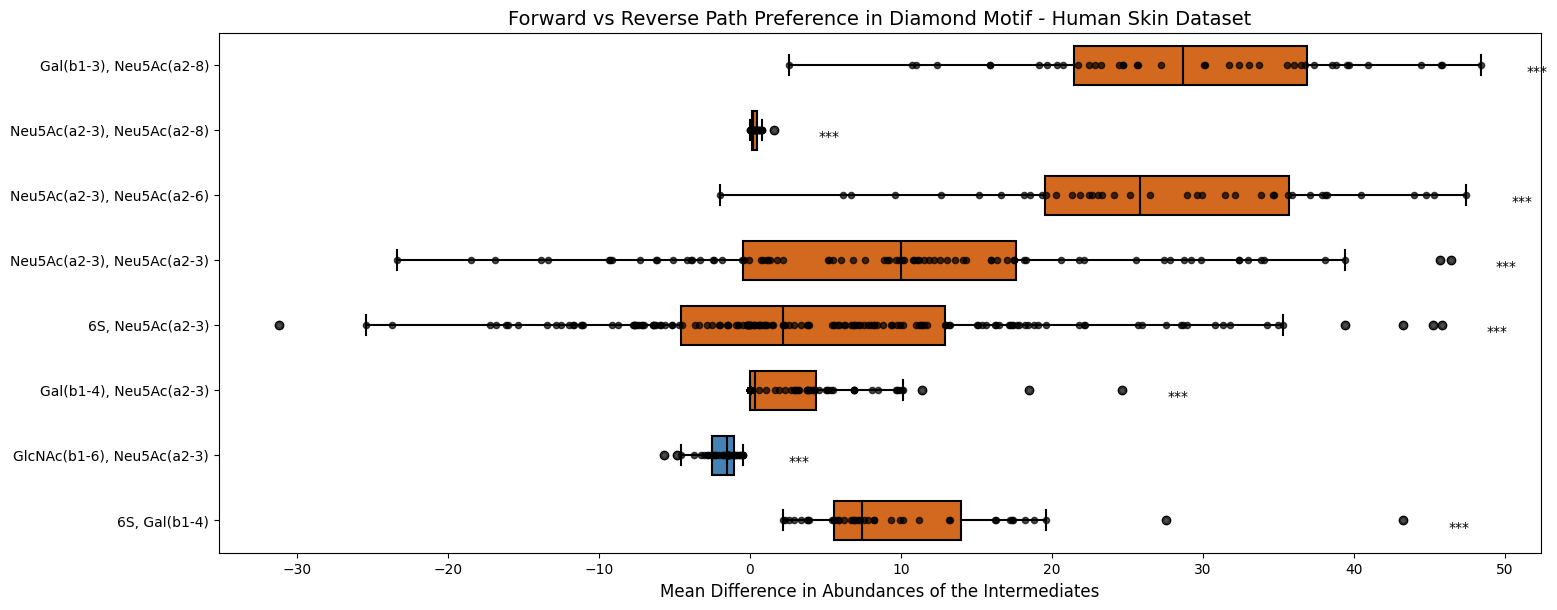

In [7]:
# Define color map for reaction direction
color_map = {
    'forward': '#4682B4',        # Steel Blue (forward)
    'reverse': '#D2691E'         # Chocolate (reverse)
}

# Define SNFG colors for monosaccharides
snfg_color_map = {
    'Fuc': '#FF0000',            # Red (Fucose)
    'Gal': '#FFD700',            # Yellow (Galactose)
    'GlcNAc': '#87CEEB',         # Light Blue (N-Acetylglucosamine)
    'Neu5Ac': '#8A2BE2',         # Purple (N-Acetylneuraminic acid)
    'GalNAc': '#FFD700',         # yellow (N-Acetylgalactosamine)
    'Man': '#32CD32',            # Green (Mannose)
    'Glc': '#0000FF'             # Blue (Glucose)
}

# Define short labels for significance levels
short_significance_labels = {
    'n.s., not significant': 'n.s.',
    '* p < 0.05': '*',
    '** p < 0.01': '**',
    '*** p < 0.001': '***'
}
filtered_results_welch_df = results_welch_df[
    (results_welch_df['Significance'] != 'n.s., not significant')
]

# Sort data for clean presentation
results_welch_df_sorted =  filtered_results_welch_df.sort_values(
    by=['Diff 2', 'Mean Difference (Abundance 1 - Abundance 2)'],
    ascending=[False, False]
)
# Set up figure
plt.figure(figsize=(16, len(results_welch_df_sorted) * 0.8))
plt.rcParams['font.family'] = 'DejaVu Sans'

# Collect data for box plot and overlay distribution
box_plot_data = []
scatter_data_x = []
scatter_data_y = []
labels = []
colors = []
for i, (index, row) in enumerate(results_welch_df_sorted.iterrows()):
    diff1 = row['Diff 1']
    diff2 = row['Diff 2']
    addition_label = f"{diff1}, {diff2}"
    color = color_map.get(row['Reaction Preference'], color_map['forward'])

    # Add data for box plot from the original df_combined DataFrame
    combined_group = df_combined[(
        (df_combined['Glycan reaction addition 1'] == diff1) & (df_combined['Glycan reaction addition 2'] == diff2)) |
        ((df_combined['Glycan reaction addition 1'] == diff2) & (df_combined['Glycan reaction addition 2'] == diff1))
    ]
    abundance_data = combined_group['Abundance of the reaction 1'].values - combined_group['Abundance of the reaction 2'].values
    abundance_data = abundance_data[~np.isnan(abundance_data)]
    box_plot_data.append(abundance_data)
    labels.append(addition_label)
    colors.append(color)

    # Collect data points for overlay
    scatter_data_x.extend(abundance_data)
    scatter_data_y.extend([i + 1] * len(abundance_data))

# Create box plot for combined abundance data
box = plt.boxplot(box_plot_data, positions=np.arange(1, len(box_plot_data) + 1), vert=False, patch_artist=True, widths=0.6)

# Customize the boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Customize the whiskers, caps, and medians
for whisker in box['whiskers']:
    whisker.set(color='black', linewidth=1.5)
for cap in box['caps']:
    cap.set(color='black', linewidth=1.5)
for median in box['medians']:
    median.set(color='black', linewidth=1.5)

# Overlay data distribution as scatter points
plt.scatter(scatter_data_x, scatter_data_y, color='black', alpha=0.7, s=20, zorder=3)

# Add significance indicators above each box plot
for i, (index, row) in enumerate(results_welch_df_sorted.iterrows()):
    significance_label = short_significance_labels.get(row['Significance'], '')
    if significance_label:
        plt.text(np.max(box_plot_data[i]) + 3, i + 1.1, significance_label, ha='left', va='center', fontsize=10)

# Customize plot appearance
plt.xlabel('Mean Difference in Abundances of the Intermediates', fontsize=12)
plt.title('Forward vs Reverse Path Preference in Diamond Motif - Human Skin Dataset', fontsize=14)
plt.xticks(fontsize=10)
plt.gca().invert_yaxis()

# Customize y-tick labels without SNFG color coding
plt.yticks(np.arange(1, len(labels) + 1), labels, fontsize=10)

plt.tight_layout(rect=[0.02, 0, 1, 0.97])
plt.show()


In [8]:
# Filter rows based on 'Sample Name' to create separate DataFrames for control and tumor
df_control = df_combined[df_combined['Sample Name'].str.contains('control', case=False)].reset_index(drop=True)
df_tumor = df_combined[df_combined['Sample Name'].str.contains('tumor', case=False)].reset_index(drop=True)



In [9]:
# List to store Welch's t-test results
results_welch_control = []

# Dictionary to track which pairs have been processed (always store sorted pairs)
processed_pairs = {}

# Group by 'Diff 1' and 'Diff 2' and aggregate data across the groups
for (diff1, diff2), group in df_control.groupby(['Glycan reaction addition 1', 'Glycan reaction addition 2']):
    # Always maintain consistent ordering of diff pairs
    diff1, diff2 = sorted([diff1, diff2])

    # Create a tuple for consistent tracking of processed pairs
    diff_pair = (diff1, diff2)

    # If this pair has already been processed, add the new group to the existing data
    if diff_pair in processed_pairs:
        processed_pairs[diff_pair] = pd.concat([processed_pairs[diff_pair], group], ignore_index=True)
    else:
        # Store the initial group for this pair
        processed_pairs[diff_pair] = group

# Iterate through combined groups to perform the Welch's t-test
for diff_pair, control_group in processed_pairs.items():
    if len(control_group) >= 2:  # Ensure we have enough data points in each group
        # Perform Welch’s t-test on abundance of the intermediates
        group1 = control_group['Abundance of the reaction 1'].dropna()
        group2 = control_group['Abundance of the reaction 2'].dropna()

        if len(group1) > 1 and len(group2) > 1:  # Ensure adequate data in both groups
            t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
            mean_diff = group1.mean() - group2.mean()
            std_dev = np.sqrt(group1.var() / len(group1) + group2.var() / len(group2))  # Combined std error

            # Assign p-value interpretation
            if p_value < 0.001:
                significance = '*** p < 0.001'
            elif p_value < 0.01:
                significance = '** p < 0.01'
            elif p_value < 0.05:
                significance = '* p < 0.05'
            else:
                significance = 'n.s., not significant'

            # Determine reaction preference based on mean difference between abundances
            if mean_diff > 0:
                reaction_preference = 'reverse'
            elif mean_diff < 0:
                reaction_preference = 'forward'
            else:
                reaction_preference = 'no preference'

            # Store the results in the table
            results_welch_control.append({
                'Diff 1': diff_pair[0],
                'Diff 2': diff_pair[1],
                'Mean Difference (Abundance 1 - Abundance 2)': mean_diff,
                'Welch T-Statistic': t_stat,
                'Welch P-Value': p_value,
                'Significance': significance,
                'Reaction Preference': reaction_preference,
                'Error': std_dev
            })

# Convert results to DataFrame
results_welch_control_df = pd.DataFrame(results_welch_control)


In [10]:
#List to store Welch's t-test results
results_welch_tumor = []

# Dictionary to track which pairs have been processed (always store sorted pairs)
processed_pairs = {}

# Group by 'Diff 1' and 'Diff 2' and aggregate data across the groups
for (diff1, diff2), group in df_tumor.groupby(['Glycan reaction addition 1', 'Glycan reaction addition 2']):
    # Always maintain consistent ordering of diff pairs
    diff1, diff2 = sorted([diff1, diff2])

    # Create a tuple for consistent tracking of processed pairs
    diff_pair = (diff1, diff2)

    # If this pair has already been processed, add the new group to the existing data
    if diff_pair in processed_pairs:
        processed_pairs[diff_pair] = pd.concat([processed_pairs[diff_pair], group], ignore_index=True)
    else:
        # Store the initial group for this pair
        processed_pairs[diff_pair] = group

# Iterate through combined groups to perform the Welch's t-test
for diff_pair, tumor_group in processed_pairs.items():
    if len(tumor_group) >= 2:  # Ensure we have enough data points in each group
        # Perform Welch’s t-test on abundance of the intermediates
        group1 = tumor_group['Abundance of the reaction 1'].dropna()
        group2 = tumor_group['Abundance of the reaction 2'].dropna()

        if len(group1) > 1 and len(group2) > 1:  # Ensure adequate data in both groups
            t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
            mean_diff = group1.mean() - group2.mean()
            std_dev = np.sqrt(group1.var() / len(group1) + group2.var() / len(group2))  # Combined std error

            # Assign p-value interpretation
            if p_value < 0.001:
                significance = '*** p < 0.001'
            elif p_value < 0.01:
                significance = '** p < 0.01'
            elif p_value < 0.05:
                significance = '* p < 0.05'
            else:
                significance = 'n.s., not significant'

            # Determine reaction preference based on mean difference between abundances
            if mean_diff > 0:
                reaction_preference = 'reverse'
            elif mean_diff < 0:
                reaction_preference = 'forward'
            else:
                reaction_preference = 'no preference'

            # Store the results in the table
            results_welch_tumor.append({
                'Diff 1': diff_pair[0],
                'Diff 2': diff_pair[1],
                'Mean Difference (Abundance 1 - Abundance 2)': mean_diff,
                'Welch T-Statistic': t_stat,
                'Welch P-Value': p_value,
                'Significance': significance,
                'Reaction Preference': reaction_preference,
                'Error': std_dev
            })

# Convert results to DataFrame
results_welch_tumor_df = pd.DataFrame(results_welch_tumor)


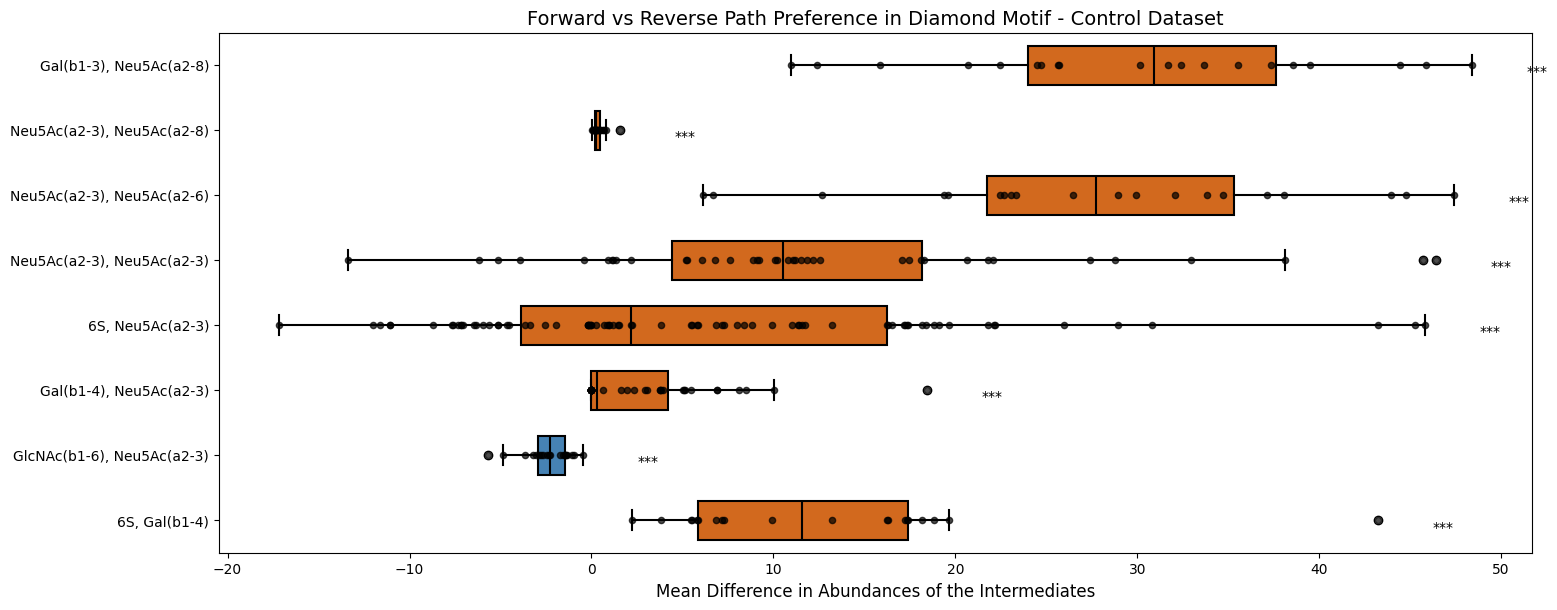

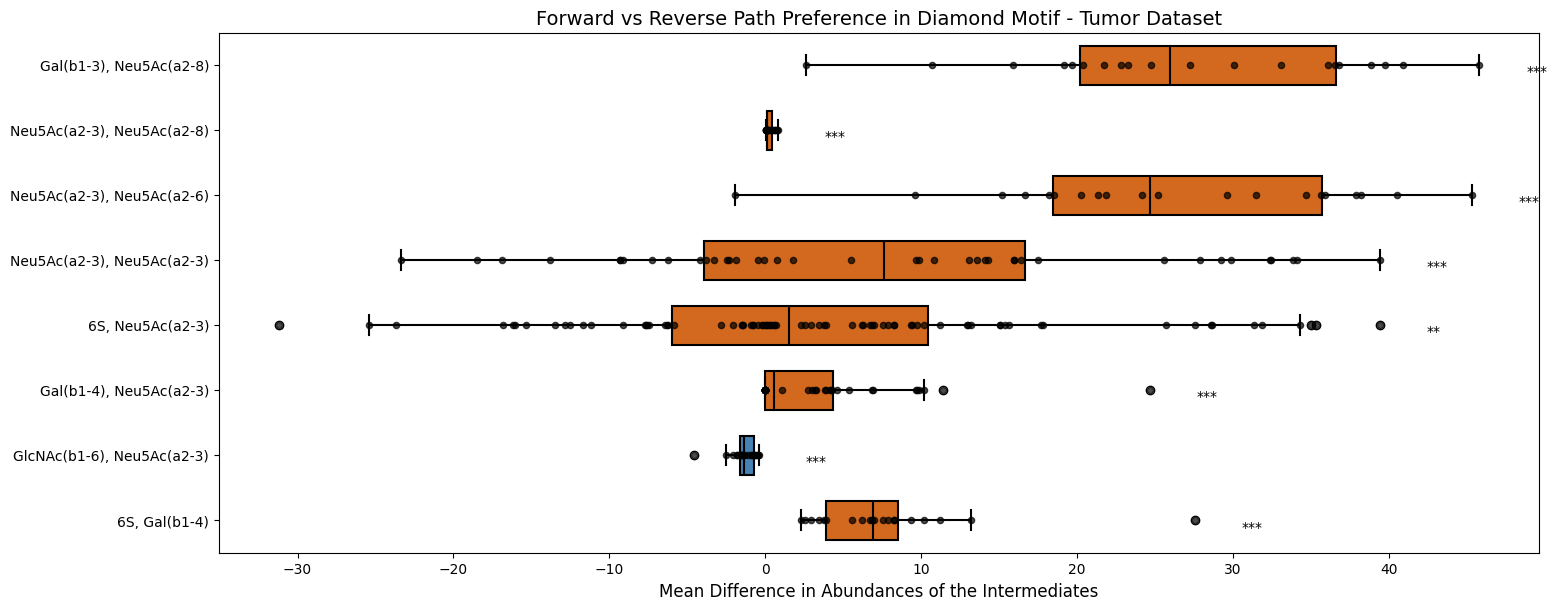

In [11]:
# Filter and sort the Control DataFrame
filtered_results_welch_control_df = results_welch_control_df[
    (results_welch_control_df['Significance'] != 'n.s., not significant')
]
results_welch_control_df_sorted = filtered_results_welch_control_df.sort_values(
    by=['Diff 2', 'Mean Difference (Abundance 1 - Abundance 2)'],
    ascending=[False, False]
)

# Plot for Control DataFrame
plt.figure(figsize=(16, len(results_welch_control_df_sorted) * 0.8))
plt.rcParams['font.family'] = 'DejaVu Sans'

# Collect data for box plot and overlay distribution for Control
box_plot_data_control = []
scatter_data_x_control = []
scatter_data_y_control = []
labels_control = []
colors_control = []
for i, (index, row) in enumerate(results_welch_control_df_sorted.iterrows()):
    diff1 = row['Diff 1']
    diff2 = row['Diff 2']
    addition_label = f"{diff1}, {diff2}"
    color = color_map.get(row['Reaction Preference'], color_map['forward'])

    # Add data for box plot from the Control DataFrame
    control_group = df_control[(
        (df_control['Glycan reaction addition 1'] == diff1) & (df_control['Glycan reaction addition 2'] == diff2)) |
        ((df_control['Glycan reaction addition 1'] == diff2) & (df_control['Glycan reaction addition 2'] == diff1))
    ]
    abundance_data_control = control_group['Abundance of the reaction 1'].values - control_group['Abundance of the reaction 2'].values
    abundance_data_control = abundance_data_control[~np.isnan(abundance_data_control)]
    box_plot_data_control.append(abundance_data_control)
    labels_control.append(addition_label)
    colors_control.append(color)

    # Collect data points for overlay
    scatter_data_x_control.extend(abundance_data_control)
    scatter_data_y_control.extend([i + 1] * len(abundance_data_control))

# Create box plot for Control abundance data
box_control = plt.boxplot(box_plot_data_control, positions=np.arange(1, len(box_plot_data_control) + 1), vert=False, patch_artist=True, widths=0.6)

# Customize the boxes for Control
for patch, color in zip(box_control['boxes'], colors_control):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Customize the whiskers, caps, and medians for Control
for whisker in box_control['whiskers']:
    whisker.set(color='black', linewidth=1.5)
for cap in box_control['caps']:
    cap.set(color='black', linewidth=1.5)
for median in box_control['medians']:
    median.set(color='black', linewidth=1.5)

# Overlay data distribution as scatter points for Control
plt.scatter(scatter_data_x_control, scatter_data_y_control, color='black', alpha=0.7, s=20, zorder=3)

# Add significance indicators above each box plot for Control
for i, (index, row) in enumerate(results_welch_control_df_sorted.iterrows()):
    significance_label = short_significance_labels.get(row['Significance'], '')
    if significance_label:
        plt.text(np.max(box_plot_data_control[i]) + 3, i + 1.1, significance_label, ha='left', va='center', fontsize=10)

# Customize plot appearance for Control
plt.xlabel('Mean Difference in Abundances of the Intermediates', fontsize=12)
plt.title('Forward vs Reverse Path Preference in Diamond Motif - Control Dataset', fontsize=14)
plt.xticks(fontsize=10)
plt.gca().invert_yaxis()

# Customize y-tick labels without SNFG color coding for Control
plt.yticks(np.arange(1, len(labels_control) + 1), labels_control, fontsize=10)

plt.tight_layout(rect=[0.02, 0, 1, 0.97])
plt.show()

# Filter and sort the Tumor DataFrame
filtered_results_welch_tumor_df = results_welch_tumor_df[
    (results_welch_tumor_df['Significance'] != 'n.s., not significant')
]
results_welch_tumor_df_sorted = filtered_results_welch_tumor_df.sort_values(
    by=['Diff 2', 'Mean Difference (Abundance 1 - Abundance 2)'],
    ascending=[False, False]
)

# Plot for Tumor DataFrame
plt.figure(figsize=(16, len(results_welch_tumor_df_sorted) * 0.8))
plt.rcParams['font.family'] = 'DejaVu Sans'

# Collect data for box plot and overlay distribution for Tumor
box_plot_data_tumor = []
scatter_data_x_tumor = []
scatter_data_y_tumor = []
labels_tumor = []
colors_tumor = []
for i, (index, row) in enumerate(results_welch_tumor_df_sorted.iterrows()):
    diff1 = row['Diff 1']
    diff2 = row['Diff 2']
    addition_label = f"{diff1}, {diff2}"
    color = color_map.get(row['Reaction Preference'], color_map['forward'])

    # Add data for box plot from the Tumor DataFrame
    tumor_group = df_tumor[(
        (df_tumor['Glycan reaction addition 1'] == diff1) & (df_tumor['Glycan reaction addition 2'] == diff2)) |
        ((df_tumor['Glycan reaction addition 1'] == diff2) & (df_tumor['Glycan reaction addition 2'] == diff1))
    ]
    abundance_data_tumor = tumor_group['Abundance of the reaction 1'].values - tumor_group['Abundance of the reaction 2'].values
    abundance_data_tumor = abundance_data_tumor[~np.isnan(abundance_data_tumor)]
    box_plot_data_tumor.append(abundance_data_tumor)
    labels_tumor.append(addition_label)
    colors_tumor.append(color)

    # Collect data points for overlay
    scatter_data_x_tumor.extend(abundance_data_tumor)
    scatter_data_y_tumor.extend([i + 1] * len(abundance_data_tumor))

# Create box plot for Tumor abundance data
box_tumor = plt.boxplot(box_plot_data_tumor, positions=np.arange(1, len(box_plot_data_tumor) + 1), vert=False, patch_artist=True, widths=0.6)

# Customize the boxes for Tumor
for patch, color in zip(box_tumor['boxes'], colors_tumor):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Customize the whiskers, caps, and medians for Tumor
for whisker in box_tumor['whiskers']:
    whisker.set(color='black', linewidth=1.5)
for cap in box_tumor['caps']:
    cap.set(color='black', linewidth=1.5)
for median in box_tumor['medians']:
    median.set(color='black', linewidth=1.5)

# Overlay data distribution as scatter points for Tumor
plt.scatter(scatter_data_x_tumor, scatter_data_y_tumor, color='black', alpha=0.7, s=20, zorder=3)

# Add significance indicators above each box plot for Tumor
for i, (index, row) in enumerate(results_welch_tumor_df_sorted.iterrows()):
    significance_label = short_significance_labels.get(row['Significance'], '')
    if significance_label:
        plt.text(np.max(box_plot_data_tumor[i]) + 3, i + 1.1, significance_label, ha='left', va='center', fontsize=10)

# Customize plot appearance for Tumor
plt.xlabel('Mean Difference in Abundances of the Intermediates', fontsize=12)
plt.title('Forward vs Reverse Path Preference in Diamond Motif - Tumor Dataset', fontsize=14)
plt.xticks(fontsize=10)
plt.gca().invert_yaxis()

# Customize y-tick labels without SNFG color coding for Tumor
plt.yticks(np.arange(1, len(labels_tumor) + 1), labels_tumor, fontsize=10)

plt.tight_layout(rect=[0.02, 0, 1, 0.97])
plt.show()